In [1]:
# ============================================================
# Tree Detection + Species Classification from RGB Drone JPGs
# Pipeline: DeepForest (detection) -> CropModel (species)
# ============================================================
# STEP 1 - Install DeepForest (run once per Colab session).
# We REQUIRE DeepForest >= 2.1: only then does CropModel.load_model()
# build the species network from config.json. Older versions raise
# "CropModel is not initialized" / "unexpected keyword 'architecture'".
# For GPU: Runtime -> Change runtime type -> GPU (T4 is fine).

!pip install -q -U "deepforest>=2.1"

# >>> CRITICAL <<<
# If you have already imported/run deepforest in THIS session, the old
# version stays in memory and STEP 5 will fail. After this install:
#   Runtime menu -> Restart session  (then run from STEP 2)
# This single step fixes the recurring STEP 5 error.

# Quick version check (should print 2.1.x or higher):
import deepforest
print("DeepForest version:", deepforest.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does n

In [2]:
# STEP 2 - Imports and load the pretrained tree-detection model
from deepforest import main
from deepforest.model import CropModel
from deepforest.visualize import plot_results
import os, glob
import pandas as pd
import torch

# Load the pretrained individual-tree detector from Hugging Face
detector = main.deepforest()
detector.load_model("weecology/deepforest-tree")

# Use the GPU if one is available (much faster)
if torch.cuda.is_available():
    detector.to("cuda")
print("Device:", detector.device)

config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  129MB            

model.safetensors: downloading bytes:           |  0.00B            

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Device: cuda:0


In [3]:
# STEP 3 - Upload your JPG drone photos from your computer (all at once)
# In the file picker that appears, select EVERY image you want:
#   Windows/Linux: Ctrl+A to select all, or Ctrl/Shift-click to multi-pick
#   Mac: Cmd+A to select all, or Cmd/Shift-click to multi-pick
# Every image you pick is uploaded in one go and collected below.
from google.colab import files
import os

uploaded = files.upload()   # select all your images in the picker

# Keep only image files, sorted (ignore any non-image you may have picked)
img_exts = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
image_paths = sorted(fn for fn in uploaded if fn.lower().endswith(img_exts))

print(len(image_paths), "image(s) ready:", image_paths)


Saving DJI_20260511172123_0003_D.JPG to DJI_20260511172123_0003_D.JPG
Saving DJI_20260511172324_0017_D.JPG to DJI_20260511172324_0017_D.JPG
2 image(s) ready: ['DJI_20260511172123_0003_D.JPG', 'DJI_20260511172324_0017_D.JPG']


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

1047 predictions in overlapping windows, applying non-max suppression
529 predictions kept after non-max suppression
Detected 529 trees in DJI_20260511172123_0003_D.JPG


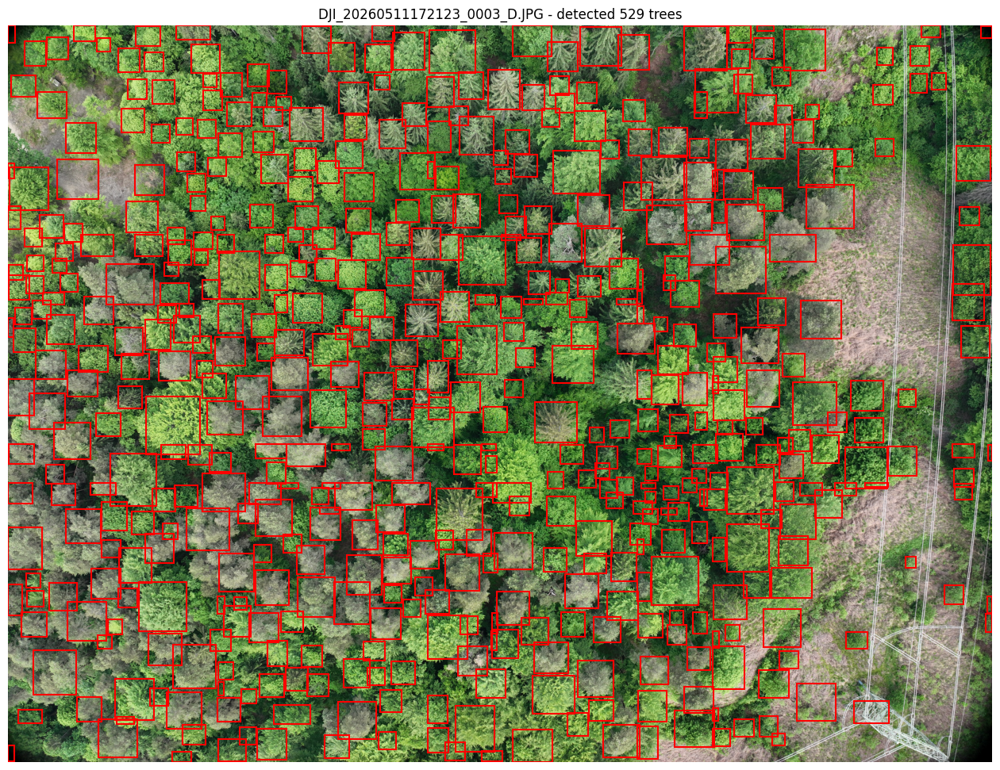

Saved overlay to step4_results/DJI_20260511172123_0003_D.JPG_detection.png


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

977 predictions in overlapping windows, applying non-max suppression
493 predictions kept after non-max suppression
Detected 493 trees in DJI_20260511172324_0017_D.JPG


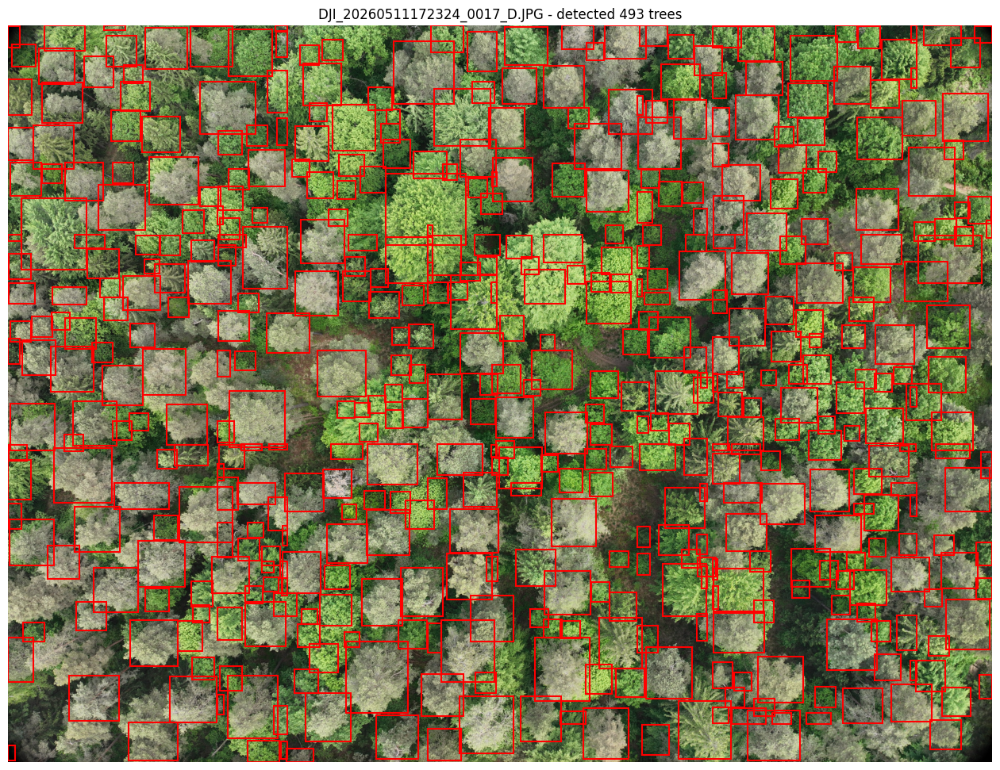

Saved overlay to step4_results/DJI_20260511172324_0017_D.JPG_detection.png

Done - 2 image(s) processed. Overlays saved in step4_results/


In [4]:
# STEP 4 - Detect individual trees in ALL uploaded JPGs
import os, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image
os.makedirs("step4_results", exist_ok=True)
detections = {}
for img_path in image_paths:
  boxes = detector.predict_tile(path=img_path, patch_size=1500, patch_overlap=0.25)
  detections[img_path] = boxes
  name = os.path.basename(img_path)
  print("Detected", len(boxes), "trees in", name)
  img = Image.open(img_path).convert("RGB")
  fig, ax = plt.subplots(figsize=(16, 16))
  ax.imshow(img)
  for _, r in boxes.iterrows():
    ax.add_patch(patches.Rectangle((r["xmin"], r["ymin"]), r["xmax"]-r["xmin"], r["ymax"]-r["ymin"], fill=False, edgecolor="red", linewidth=1.5))
  ax.set_title(f"{name} - detected {len(boxes)} trees")
  ax.axis("off")
  out_path = os.path.join("step4_results", name + "_detection.png")
  fig.savefig(out_path, dpi=150, bbox_inches="tight", pad_inches=0)
  plt.show()
  plt.close(fig)
  print("Saved overlay to", out_path)
print("\nDone -", len(image_paths), "image(s) processed. Overlays saved in step4_results/")

config.json:   0%|          | 0.00/2.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 94.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Dead-tree model ready. Classes: {'Alive': 0, 'Dead': 1}


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


1047 predictions in overlapping windows, applying non-max suppression
529 predictions kept after non-max suppression


Output()

DJI_20260511172123_0003_D.JPG -> 529 trees, 0 classified DEAD


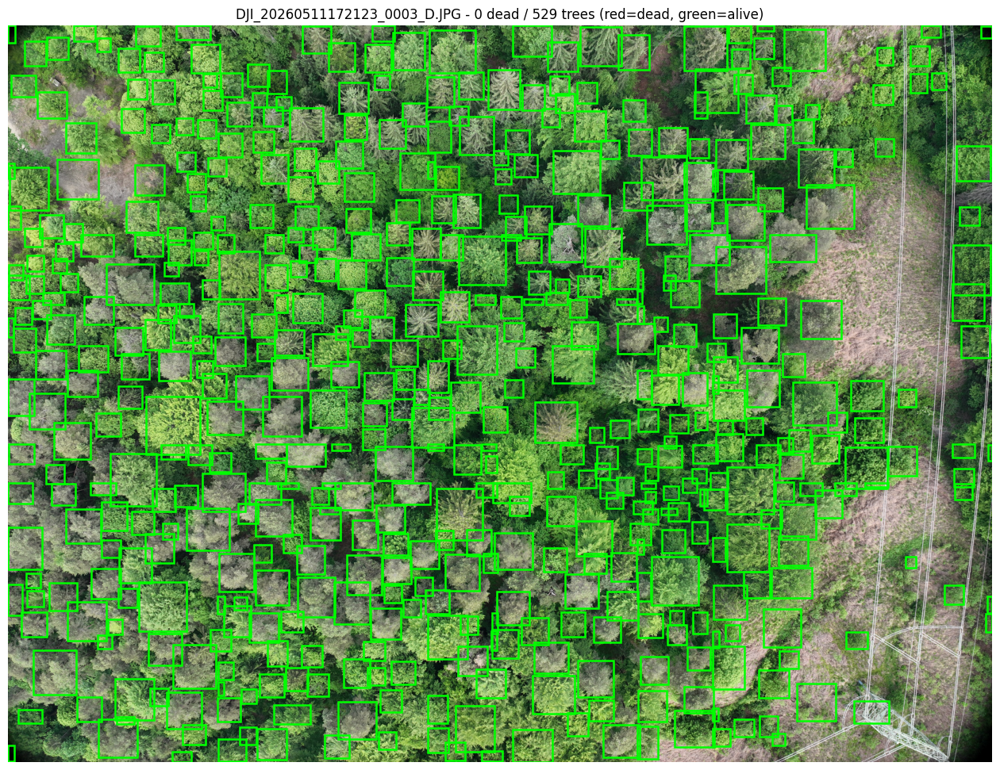

Saved overlay to deadtree_results/DJI_20260511172123_0003_D.JPG_deadtrees.png


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

977 predictions in overlapping windows, applying non-max suppression
493 predictions kept after non-max suppression


DJI_20260511172324_0017_D.JPG -> 493 trees, 0 classified DEAD


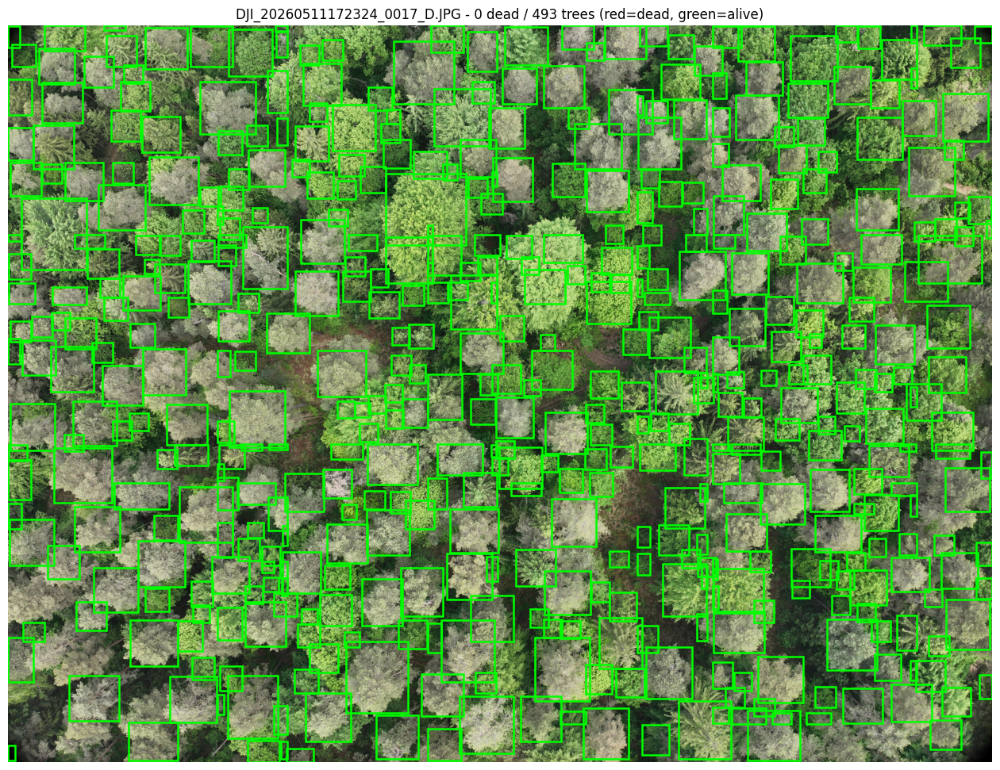

Saved overlay to deadtree_results/DJI_20260511172324_0017_D.JPG_deadtrees.png

Dead-tree detection done for 2 image(s). Overlays in deadtree_results/


In [5]:
# STEP 4.5 - Detect DEAD trees (Alive/Dead) BEFORE species classification
# Uses the official weecology/cropmodel-deadtrees CropModel, which runs on
# each detected crown and labels it Alive or Dead. Same detector as before.
import os, json, torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision import models
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from deepforest.model import CropModel

dead_repo = "weecology/cropmodel-deadtrees"
dead_cfg = json.load(open(hf_hub_download(dead_repo, "config.json")))["cropmodel"]
dead_labels = {k: int(v) for k, v in dead_cfg["label_dict"].items()}
dead_backbone = models.resnet50(weights=None)
dead_backbone.fc = torch.nn.Linear(dead_backbone.fc.in_features, len(dead_labels))
dead_model = CropModel()
dead_model.model = dead_backbone
dead_state = load_file(hf_hub_download(dead_repo, "model.safetensors"))
dead_model.load_state_dict(dead_state, strict=False)
dead_model.label_dict = dead_labels
dead_model.numeric_to_label_dict = {v: k for k, v in dead_labels.items()}
dead_model.eval()
print("Dead-tree model ready. Classes:", dead_labels)

os.makedirs("deadtree_results", exist_ok=True)
dead_detections = {}
for img_path in image_paths:
  res = detector.predict_tile(path=img_path, patch_size=1500, patch_overlap=0.25, crop_model=dead_model)
  dead_detections[img_path] = res
  name = os.path.basename(img_path)
  n_dead = int((res["cropmodel_label"] == dead_labels["Dead"]).sum())
  print(name, "->", len(res), "trees,", n_dead, "classified DEAD")
  img = Image.open(img_path).convert("RGB")
  fig, ax = plt.subplots(figsize=(16, 16))
  ax.imshow(img)
  for _, r in res.iterrows():
    color = "red" if r["cropmodel_label"] == dead_labels["Dead"] else "lime"
    ax.add_patch(patches.Rectangle((r["xmin"], r["ymin"]), r["xmax"]-r["xmin"], r["ymax"]-r["ymin"], fill=False, edgecolor=color, linewidth=1.8))
  ax.set_title(f"{name} - {n_dead} dead / {len(res)} trees (red=dead, green=alive)")
  ax.axis("off")
  out_path = os.path.join("deadtree_results", name + "_deadtrees.png")
  fig.savefig(out_path, dpi=150, bbox_inches="tight", pad_inches=0)
  plt.show()
  plt.close(fig)
  print("Saved overlay to", out_path)
print("\nDead-tree detection done for", len(image_paths), "image(s). Overlays in deadtree_results/")

Species model ready: resnet18 with 148 classes


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

977 predictions in overlapping windows, applying non-max suppression
493 predictions kept after non-max suppression


     xmin    ymin    xmax    ymax     score cropmodel_label  cropmodel_score
0  1541.0  1319.0  1772.0  1557.0  0.753660          CADE27         0.079756
1  3597.0  3627.0  3879.0  3938.0  0.701894           PIPA2         0.097723
2  1572.0  1043.0  1804.0  1277.0  0.680276            QUKE         0.150637
3  2422.0  3600.0  2712.0  3909.0  0.674558           PIPA2         0.127566
4  3783.0  3147.0  4056.0  3370.0  0.657110            QUKE         0.111370


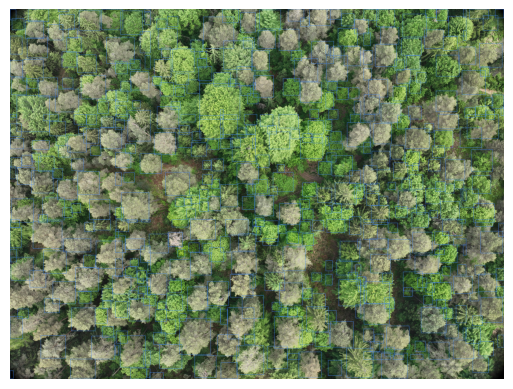

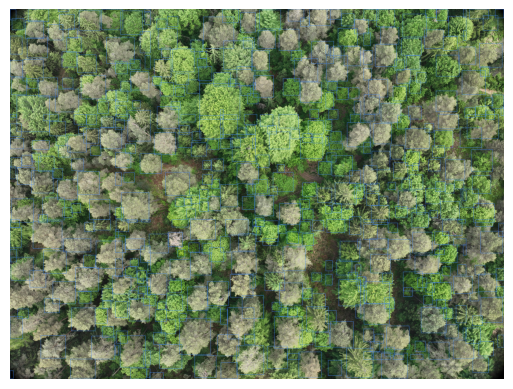

In [7]:
# STEP 5 - Classify each detected crown into a species (CropModel)
# Demo model: 148 NEON (North American) species. Accuracy is low
# (~39%) and geographically biased - retrain on local crops for
# real use (see DeepForest 'CropModel' docs).
#
# NOTE: the installed DeepForest build's create_model() does NOT accept
# an 'architecture' argument (its signature differs from the online
# docs). So we build the resnet18 backbone OURSELVES with torchvision
# and attach it to the CropModel. This is version-independent and
# matches the checkpoint exactly (resnet18, fc -> 148 classes).

import json
import torch
from torchvision import models
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

repo = "weecology/cropmodel-tree-species"

# Read the model's own config: architecture + species label map
cfg = json.load(open(hf_hub_download(repo, "config.json")))["cropmodel"]
label_dict   = {k: int(v) for k, v in cfg["label_dict"].items()}
architecture = cfg.get("architecture", "resnet18")   # -> "resnet18"
num_classes  = len(label_dict)                        # -> 148

# Build the exact backbone the checkpoint expects (resnet18 head=148)
assert architecture == "resnet18", f"Unexpected architecture: {architecture}"
backbone = models.resnet18(weights=None)
backbone.fc = torch.nn.Linear(backbone.fc.in_features, num_classes)

# Create the CropModel and attach our backbone directly,
# bypassing create_model() (whose signature varies by version).
species_model = CropModel()
species_model.model = backbone

# Load the pretrained species weights. Keys are stored under the
# "model." prefix, which maps onto species_model.model.
state = load_file(hf_hub_download(repo, "model.safetensors"))
species_model.load_state_dict(state, strict=False)

# Attach the human-readable label maps and switch to eval mode
species_model.label_dict = label_dict
species_model.numeric_to_label_dict = {v: k for k, v in label_dict.items()}
species_model.eval()
print("Species model ready:", architecture, "with", num_classes, "classes")

# Run detection + per-crown species classification on one image
results = detector.predict_tile(
    path=img_path,
    patch_size=1500,
    patch_overlap=0.25,
    crop_model=species_model,   # adds species columns
)

# New columns: cropmodel_label (species) and cropmodel_score (confidence)
print(results[["xmin", "ymin", "xmax", "ymax", "score",
               "cropmodel_label", "cropmodel_score"]].head())
plot_results(results)

In [8]:
# STEP 6 - Batch process a whole folder of JPGs into one table
all_results = []
for path in image_paths:
    df = detector.predict_tile(
        path=path,
        patch_size=600,
        patch_overlap=0.25,
        crop_model=species_model,
    )
    df["image_path"] = os.path.basename(path)
    all_results.append(df)

combined = pd.concat(all_results, ignore_index=True)
print("Total trees across all images:", len(combined))
combined.head()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

5096 predictions in overlapping windows, applying non-max suppression
3145 predictions kept after non-max suppression


...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

4422 predictions in overlapping windows, applying non-max suppression
2662 predictions kept after non-max suppression


Total trees across all images: 5807


,xmin,ymin,xmax,ymax,label,score,image_path,cropmodel_label,cropmodel_score,geometry
0,2204.0,1801.0,2359.0,1955.0,Tree,0.799195,DJI_20260511172123_0003_D.JPG,JUNI,0.125807,"POLYGON ((2359 1801, 2359 1955, 2204 1955, 220..."
1,2302.0,917.0,2396.0,1033.0,Tree,0.775206,DJI_20260511172123_0003_D.JPG,JUNI,0.069663,"POLYGON ((2396 917, 2396 1033, 2302 1033, 2302..."
2,3183.0,3203.0,3282.0,3299.0,Tree,0.774547,DJI_20260511172123_0003_D.JPG,QUKE,0.119992,"POLYGON ((3282 3203, 3282 3299, 3183 3299, 318..."
3,2015.0,500.0,2109.0,599.0,Tree,0.745786,DJI_20260511172123_0003_D.JPG,QUKE,0.063313,"POLYGON ((2109 500, 2109 599, 2015 599, 2015 5..."
4,2318.0,1422.0,2461.0,1579.0,Tree,0.733718,DJI_20260511172123_0003_D.JPG,JUNI,0.098697,"POLYGON ((2461 1422, 2461 1579, 2318 1579, 231..."


In [ ]:
# STEP 7 - Save the per-tree results (box + species + confidence)
# Coordinates are in pixels. To get geographic coordinates, first
# stitch the JPGs into a georeferenced orthomosaic (e.g. OpenDroneMap)
# and run this pipeline on the resulting GeoTIFF instead.
combined.to_csv("tree_detections_with_species.csv", index=False)
print("Saved -> tree_detections_with_species.csv")

# Download it from Colab to your computer:
files.download("tree_detections_with_species.csv")